In [1]:
import json
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from scipy.stats import spearmanr

In [3]:
from tqdm.notebook import tqdm

In [4]:
import glob
import re

In [14]:
files = sorted(glob.glob('./*din_app*'))

In [64]:
files = sorted(glob.glob('../Linkdin_results/*app*'))

In [65]:
files

['../Linkdin_results/results_app_partial_-1_to_9999.npy',
 '../Linkdin_results/results_app_partial_19999_to_29999.npy',
 '../Linkdin_results/results_app_partial_29999_to_33243.npy',
 '../Linkdin_results/results_app_partial_9999_to_19999.npy']

In [66]:
def extract_number(file_path):
    match = re.search(r'(\d+)_to_', file_path)
    if match:
        return int(match.group(1))
    return 0  # Return 0 or some other default value if no number is found

# Sorting the list using the extract_number function as key
sorted_file_paths = sorted(files, key=extract_number)

In [67]:
sorted_file_paths

['../Linkdin_results/results_app_partial_-1_to_9999.npy',
 '../Linkdin_results/results_app_partial_9999_to_19999.npy',
 '../Linkdin_results/results_app_partial_19999_to_29999.npy',
 '../Linkdin_results/results_app_partial_29999_to_33243.npy']

In [68]:
arrays = [np.load(file, allow_pickle=True) for file in sorted_file_paths]

# Concatenate all arrays into a single array
combined_array = np.concatenate(arrays)

# Now combined_array contains all the data 

In [69]:
combined_array.shape

(33243, 2)

In [41]:
combined_array[:5,:]

array([[0,
        {'word': [('hearing', 0.7629646), ('##life', 0.008714888), ('is', 0.9621095), ('national', 0.0017667538), ('hearing', 0.99388796), ('care', 0.09845988), ('company', 0.2742641), ('and', 0.40543216), ('part', 0.77233326), ('dem', 2.3423577e-06), ('##ant', 0.00015390811), ('group', 0.8516271), ('global', 0.5584472), ('leader', 0.7702852), ('hearing', 0.5621177), ('healthcare', 0.0029018954), ('built', 0.02670631), ('heritage', 0.00043866335), ('care', 0.004162662), ('health', 0.0042981314), ('and', 0.9970708), ('innovation', 0.05576662), ('hearing', 0.5783357), ('##life', 0.007475684), ('operates', 0.29490846), ('more', 0.99986315), ('than', 0.99978966), ('hearing', 0.9910589), ('care', 0.191287), ('centers', 0.21189193), ('states', 0.012851113), ('we', 0.019504838), ('follow', 0.043026637), ('scientific', 0.0076945024), ('results', 0.0015208247), ('oriented', 0.12674184), ('approach', 0.98541695), ('hearing', 2.2791193e-05), ('healthcare', 0.0005299943), ('is', 0.99743

In [21]:
with open('final_app_results.json', 'r') as f:
    full_result_label = json.load(f)

In [21]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

def corr_analysis(list1,list2):
    # Calculate correlation coefficient
    from scipy.stats import spearmanr
    corr_coefficient, p_value = spearmanr(list1, list2)
    print(corr_coefficient)
    #corr_coefficient = np.corrcoef(list1, list2)[0, 1]

    # Plot
    plt.scatter(list1, list2)
    plt.title(f'Correlation plot (r = {corr_coefficient:.2f})')
    plt.xlabel('score')
    plt.ylabel('Labeled value')
    plt.grid(True)
    plt.show()


## Test the rank

In [24]:
import pickle
with open('../valid_word_dict.pkl', 'rb') as f:
    valid_word_dict = pickle.load(f)

In [70]:
def filter_and_rank_scores(all_word_scores, alpha=100):
    # Sort and rank words based on their scores
    sorted_scores = sorted(all_word_scores, key=lambda x: x[1], reverse=True)  # in desending order, from highest to lowest
    total_words = len(sorted_scores)
    alpha_threshold = int(np.ceil(total_words * (alpha / 100.0)))  # Determine the rank threshold for alpha quantile
    filtered_scores = sorted_scores[:alpha_threshold]  # Keep only scores within the alpha to 100th percentile
    
    # Generate rankings for the filtered set of words
    rankings = {word: rank + 1 for rank, (word, _) in enumerate(filtered_scores)}
    return rankings, filtered_scores

def compute_mean_ranking(rankings, word_list):
    ranks = [rankings.get(word) for word in word_list if word in rankings]  # Consider only ranked (filtered-in) words
    mean_rank = sum(ranks) / len(ranks) if ranks else None  # Return None if no words from the list were ranked
    return mean_rank



full_result_all_keys = {}

for key in ['psy', 'role', 'wfc', 'gsc']:
    full_values_per_paragraph = [None] * 33244
    words_per_paragraph = []

    #key = 'psy'
    alpha = 20+3

    for para_index, paragraph in tqdm(combined_array):
        if paragraph is None:
            full_values_per_paragraph[para_index] = None
            continue
        temp_full_value = []
        temp_words = []


        words, probs = zip(*paragraph['word'])
        words = list(words)
        directions = list(valid_word_dict[key].keys())
        combined_scores_for_whole_paragraph = [None] * len(words)
        # Iterate over words and their scores for each direction
        for index in range(len(words)):
            combined_scores_each_word = []
            for direction in directions:
                ndarray = paragraph[key][direction]    
                scores = ndarray[index]  # Assuming each row corresponds to a word
                for word, score in zip(valid_word_dict[key][direction], scores):
                    combined_scores_each_word.append((word, score))
            combined_scores_for_whole_paragraph[index] = combined_scores_each_word
        # Calculate the mean score for th


        for word, combined_scores_each_word in zip(words,combined_scores_for_whole_paragraph):
            try:
                combined_rankings, filtered_scores = filter_and_rank_scores(combined_scores_each_word, alpha)

                mean_ranking = {}
                for direction in directions:
                    word_list = valid_word_dict[key][direction]
                    filtered_direction_words = [word for word, score in filtered_scores if word in word_list]
                    direction_rankings = {word: combined_rankings[word] for word in filtered_direction_words}
                    mean_ranking[direction] = compute_mean_ranking(combined_rankings, filtered_direction_words)

                if mean_ranking['fem'] is None:
                    score = 2*mean_ranking['mas']
                elif mean_ranking['mas'] is None:
                    score = -2*mean_ranking['fem']
                else:
                    score = mean_ranking['fem'] - mean_ranking['mas']

                temp_words.append(word)  
                temp_full_value.append(score)  
            except Exception as e:
                print(e)
                pass

        # Calculate the mean score for the paragraph
        if temp_full_value:
            paragraph_mean_score = np.mean(temp_full_value)
            full_values_per_paragraph[para_index] = paragraph_mean_score
        words_per_paragraph.append(temp_words)
    
    full_result_all_keys[key] = full_values_per_paragraph
    
    
    
# After processing all paragraphs
print(f'Total number of paragraphs: {len(full_values_per_paragraph)}')


  0%|          | 0/33243 [00:00<?, ?it/s]

  0%|          | 0/33243 [00:00<?, ?it/s]

  0%|          | 0/33243 [00:00<?, ?it/s]

  0%|          | 0/33243 [00:00<?, ?it/s]

Total number of paragraphs: 33244


In [33]:
result_df_app = pd.DataFrame(full_result_all_keys)

In [34]:
result_df_app

,psy,role,wfc,gsc
0,-0.950213,3.314653,-0.349187,0.292683
1,-0.036755,4.735731,0.080231,1.004329
2,0.629544,3.652494,0.262273,0.852273
3,0.113772,3.263196,-0.047325,0.109053
4,0.115120,2.376648,-0.274797,0.893728
...,...,...,...,...
33238,0.457880,3.940663,0.338114,0.503876
33239,-0.005578,4.173079,0.048867,0.385922
33240,-0.682063,3.761776,-0.434799,0.629630
33241,-0.524513,3.519185,-0.699741,0.457198


In [71]:
result_df_job = pd.DataFrame(full_result_all_keys)

In [72]:
result_df_job

,psy,role,wfc,gsc
0,-0.950213,3.314653,0.811271,0.292683
1,-0.036755,4.735731,0.403016,1.004329
2,0.629544,3.652494,0.234541,0.852273
3,0.113772,3.263196,0.623034,0.109053
4,0.115120,2.376648,0.420125,0.893728
...,...,...,...,...
33239,0.457880,3.940663,0.762745,0.503876
33240,-0.005578,4.173079,0.858746,0.385922
33241,-0.682063,3.761776,0.300795,0.629630
33242,-0.524513,3.519185,0.084634,0.457198


In [73]:
result_df_job.to_csv('./app_result.csv',index=False)

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
result_df_job = pd.read_csv('./job_result.csv')
result_df_app = pd.read_csv('./app_result.csv')

In [80]:
from sklearn.cluster import DBSCAN
def remove_outliers_with_dbscan(x, y, eps=0.5, min_samples=30):
    """
    Removes outliers from the given datasets x and y using the DBSCAN clustering method.
    
    Parameters:
        x (array_like): Dataset 1.
        y (array_like): Dataset 2, must be the same length as x.
        eps (float, optional): The maximum distance between two samples for one to be considered 
            as in the neighborhood of the other. Default is 0.5.
        min_samples (int, optional): The number of samples in a neighborhood for a point to be considered 
            as a core point. Default is 10.
    
    Returns:
        np.ndarray: Filtered dataset x without outliers.
        np.ndarray: Filtered dataset y without outliers.
        int: Number of points filtered.
    """
    assert len(x) == len(y), "x and y must have the same length"
    
    # Combine x and y into a single array and remove any rows with NaN values
    data = np.stack((x, y), axis=-1)
    data = data[~np.isnan(data).any(axis=1)]
    
    original_length = len(data)
    
    # Applying DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(data)
    labels = db.labels_
    
    # Points with label -1 are considered outliers
    filtered_data = data[labels != -1]
    filtered_length = len(filtered_data)
    
    # Calculate the number and percentage of points filtered
    num_filtered = original_length - filtered_length
    percent_filtered = (num_filtered / original_length) * 100
    
    return filtered_data[:, 0], filtered_data[:, 1], num_filtered, percent_filtered


Filtered out 31 data points (0.09% of the original data).
Correlation (r) between psy and psy: 0.644
Slope: 0.489
Intercept: 0.053
P-value: 0.000
Filtered out 153 data points (0.46% of the original data).
Correlation (r) between role and role: 0.708
Slope: 0.484
Intercept: 1.476
P-value: 0.000
Filtered out 7 data points (0.02% of the original data).
Correlation (r) between wfc and wfc: 0.451
Slope: 0.316
Intercept: 0.369
P-value: 0.000
Filtered out 8 data points (0.02% of the original data).
Correlation (r) between gsc and gsc: 0.777
Slope: 0.629
Intercept: 0.276
P-value: 0.000


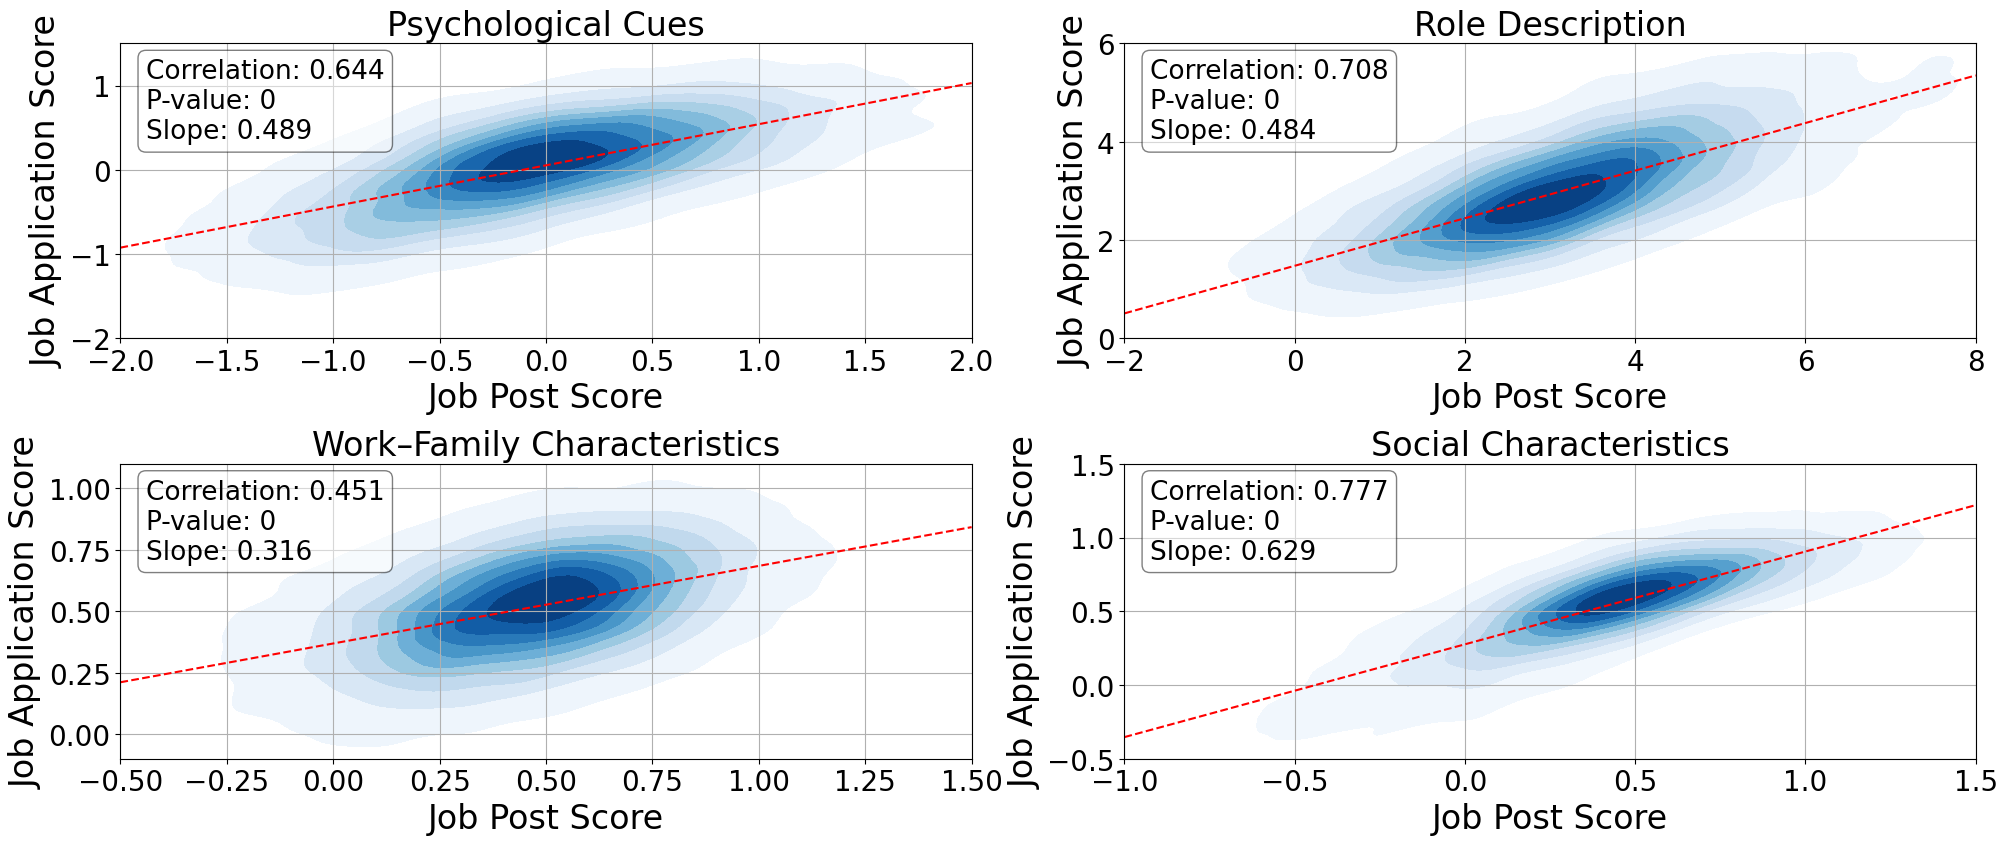

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr

# Assuming remove_outliers_with_dbscan and dataframes result_df_job and result_df_app are defined
# Assuming name_list, and correlation tests are needed between columns of result_df_job and result_df_app


xlims = [(-2, 2), (-2, 8), (-0.5, 1.5), (-1, 1.5)]  # Example limits
ylims = [(-2, 1.5), (0, 6), (-0.1, 1.1), (-0.5, 1.5)]  # Example limits


# Determine the grid size
n = len(result_df_job.columns)
rows = int(n**0.5) + 1
cols = (n // rows) + 1

fig, axes = plt.subplots(rows, cols, figsize=(10*cols, 4*rows))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust space between plots

# Flatten the axes array for easy iteration
axes = axes.flatten()

column_pairs = [(job, app) for job, app in zip(result_df_job.columns, result_df_app.columns)]

# Loop through each pair and create a density plot
for i, (col1, col2) in enumerate(column_pairs):
    filtered_X, filtered_Y, num_filtered, percent_filtered = remove_outliers_with_dbscan(result_df_job[col1], result_df_app[col2])
    print(f"Filtered out {num_filtered} data points ({percent_filtered:.2f}% of the original data).")

    ax = axes[i]
    # Create a density plot with a 2D Gaussian Kernel Density Estimate
    sns.kdeplot(x=filtered_X, y=filtered_Y, ax=ax, cmap="Blues", fill=True)
    ax.set_title(f'{name_list[i]}', fontsize=24)
    ax.set_xlabel(f'Job Post Score', fontsize=24)
    ax.set_ylabel(f'Job Application Score', fontsize=24)
    # Set the font size of the tick labels
    ax.tick_params(axis='both', which='major', labelsize=20)  # Set the size of the tick labels on both axes
    ax.grid(True)
    
    
    # Manually set x and y limits
    ax.set_xlim(xlims[i % len(xlims)])  # Using modulo to avoid index out of range if there are more plots than defined limits
    ax.set_ylim(ylims[i % len(ylims)])

    # # Correlation analysis
    # correlation, p_value = pearsonr(filtered_X, filtered_Y)
    # print(f"Correlation between {col1} and {col2}: {correlation:.3f}, p-value: {p_value:.3f}")
    # Linear regression analysis
    regression_results = linregress(filtered_X, filtered_Y)
    slope = regression_results.slope
    intercept = regression_results.intercept
    correlation = regression_results.rvalue
    p_value = regression_results.pvalue
    
    print(f"Correlation (r) between {col1} and {col2}: {correlation:.3f}")
    print(f"Slope: {slope:.3f}")
    print(f"Intercept: {intercept:.3f}")
    print(f"P-value: {p_value:.3f}")

    # Optional: Plot regression line
    x_vals = np.array(ax.get_xlim())
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, '--', color='red')
    
    # # Display correlation, p-value, and slope within the plot
    ax.text(0.03, 0.95, f'Correlation: {correlation:.3f}\nP-value: {p_value:.3g}\nSlope: {slope:.3f}',
            transform=ax.transAxes, fontsize=19, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    # # Enhanced annotation
    # ax.annotate(f'Correlation: {correlation:.3f}\nP-value: {p_value:.3g}\nSlope: {slope:.3f}',
    #          xy=(0.5, 0.5), xycoords='data',
    #          xytext=(0.7, 0.7), textcoords='axes fraction',
    #          arrowprops=dict(facecolor='black', shrink=0.05),
    #          bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', edgecolor='black', alpha=0.75),
    #          fontsize=12)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [184]:
# Assuming result_df_job and result_df_app are defined and contain your data
column_pairs = [(job, app) for job, app in zip(result_df_job.columns, result_df_app.columns)]

# Loop through each pair
for i, (col1, col2) in enumerate(column_pairs):
    filtered_X, filtered_Y, num_filtered, percent_filtered = remove_outliers_with_dbscan(result_df_job[col1], result_df_app[col2])
    print(f"Filtered out {num_filtered} data points ({percent_filtered:.2f}% of the original data).")
    
    if len(filtered_X) > 0 and len(filtered_Y) > 0:  # Ensure there are enough data points to calculate statistics
        # Convert filtered data to pandas Series
        series_X = pd.Series(filtered_X, name='X')
        series_Y = pd.Series(filtered_Y, name='Y')
        
        # Calculate descriptive statistics for each Series
        stats_X = series_X.describe()
        stats_Y = series_Y.describe()
        
        # Combine the statistics into a DataFrame for easy comparison
        combined_stats = pd.concat([stats_X, stats_Y], axis=1)
        print(f"Combined Summary Statistics for {col1} (X) vs {col2} (Y):")
        display(combined_stats)
    else:
        print(f"Not enough data to calculate statistics for {col1} vs {col2}")

Filtered out 31 data points (0.09% of the original data).
Combined Summary Statistics for psy (X) vs psy (Y):


,X,Y
count,33038.000000,33038.000000
mean,-0.030272,0.038554
std,0.702548,0.533099
min,-2.921150,-2.017760
25%,-0.480577,-0.299648
50%,-0.041137,0.073802
75%,0.421637,0.407441
max,3.044074,1.937216


Filtered out 153 data points (0.46% of the original data).
Combined Summary Statistics for role (X) vs role (Y):


,X,Y
count,32916.000000,32916.000000
mean,3.188413,3.019625
std,1.550271,1.059724
min,-1.871965,-0.249208
25%,2.157636,2.275654
50%,3.141900,2.961724
75%,4.146956,3.701258
max,8.933600,7.081849


Filtered out 7 data points (0.02% of the original data).
Combined Summary Statistics for wfc (X) vs wfc (Y):


,X,Y
count,33062.000000,33062.000000
mean,0.455310,0.512856
std,0.289879,0.202816
min,-1.812535,-0.666028
25%,0.278969,0.383706
50%,0.465809,0.518365
75%,0.641988,0.650746
max,2.094007,1.423683


Filtered out 8 data points (0.02% of the original data).
Combined Summary Statistics for gsc (X) vs gsc (Y):


,X,Y
count,33061.000000,33061.000000
mean,0.435251,0.550172
std,0.355218,0.287906
min,-1.634615,-0.805769
25%,0.237723,0.400376
50%,0.445978,0.583756
75%,0.652720,0.743169
max,2.500000,1.565640


In [183]:
# Assuming result_df_job and result_df_app are defined and contain your data
column_pairs = [(job, app) for job, app in zip(result_df_job.columns, result_df_app.columns)]

# Loop through each pair
for i, (col1, col2) in enumerate(column_pairs):
    filtered_X, filtered_Y, num_filtered, percent_filtered = remove_outliers_with_dbscan(result_df_job[col1], result_df_app[col2])
    print(f"Filtered out {num_filtered} data points ({percent_filtered:.2f}% of the original data).")
    
    if len(filtered_X) > 0 and len(filtered_Y) > 0:  # Ensure there are enough data points to calculate statistics
        # Convert filtered data to pandas Series
        series_X = pd.Series(filtered_X, name='X')
        series_Y = pd.Series(filtered_Y, name='Y')
        
        # Calculate descriptive statistics for each Series
        stats_X = np.abs(series_X).describe()
        stats_Y = np.abs(series_Y).describe()
        
        # Combine the statistics into a DataFrame for easy comparison
        combined_stats = pd.concat([stats_X, stats_Y], axis=1)
        print(f"Combined Summary Statistics for {col1} (X) vs {col2} (Y):")
        display(combined_stats)
    else:
        print(f"Not enough data to calculate statistics for {col1} vs {col2}")

Filtered out 31 data points (0.09% of the original data).
Combined Summary Statistics for psy (X) vs psy (Y):


,X,Y
count,33038.000000,33038.000000
mean,0.552099,0.427335
std,0.435508,0.321030
min,0.000008,0.000008
25%,0.208084,0.170874
50%,0.451948,0.360943
75%,0.794728,0.618002
max,3.044074,2.017760


Filtered out 153 data points (0.46% of the original data).
Combined Summary Statistics for role (X) vs role (Y):


,X,Y
count,32916.000000,32916.000000
mean,3.205418,3.019678
std,1.514798,1.059574
min,0.000241,0.009522
25%,2.157636,2.275654
50%,3.141900,2.961724
75%,4.146956,3.701258
max,8.933600,7.081849


Filtered out 7 data points (0.02% of the original data).
Combined Summary Statistics for wfc (X) vs wfc (Y):


,X,Y
count,33062.000000,33062.000000
mean,0.476378,0.515052
std,0.253772,0.197173
min,0.000111,0.000037
25%,0.289005,0.383953
50%,0.469053,0.518374
75%,0.644077,0.650777
max,2.094007,1.423683


Filtered out 8 data points (0.02% of the original data).
Combined Summary Statistics for gsc (X) vs gsc (Y):


,X,Y
count,33061.000000,33061.000000
mean,0.483501,0.569096
std,0.286093,0.248413
min,0.000000,0.000000
25%,0.271894,0.404472
50%,0.458178,0.584388
75%,0.657495,0.743289
max,2.500000,1.565640


In [181]:
from scipy.stats import ks_2samp

# Assuming result_df_job and result_df_app are defined and contain your data
column_pairs = [(job, app) for job, app in zip(result_df_job.columns, result_df_app.columns)]

# Loop through each pair
for i, (col1, col2) in enumerate(column_pairs):
    filtered_X, filtered_Y, num_filtered, percent_filtered = remove_outliers_with_dbscan(result_df_job[col1], result_df_app[col2])
    #print(f"Filtered out {num_filtered} data points ({percent_filtered:.2f}% of the original data).")

    if len(filtered_X) > 1 and len(filtered_Y) > 1:  # Ensure there are enough data points to perform the tests
        # Perform KS test to check distribution shifts
        # ks_stat, ks_p_value = ks_2samp(filtered_X, filtered_Y,alternative='less')
        # print(f"KS test results for {name_list[i]} : D-statistic = {ks_stat}, p-value = {ks_p_value}")

        # Additional tests (t-tests and Wilcoxon) as described in the previous response
        # Normality test on the differences
        diff = filtered_X - filtered_Y
        stat, p_value = shapiro(diff)
        if p_value > 0.05:
            t_stat, p_val = ttest_rel(filtered_X, filtered_Y,alternative='less')
            print(f"Paired t-test results for {name_list[i]}: t-statistic = {t_stat}, p-value = {p_val}")
        else:
            stat, p_val = wilcoxon(filtered_X, filtered_Y,alternative='greater')
            print(f"Wilcoxon test results for {name_list[i]}: statistic = {stat}, p-value = {p_val}")

        # Test on absolute values for magnitude of bias
        abs_diff = np.abs(filtered_X) - np.abs(filtered_Y)
        abs_stat, abs_p_value = shapiro(abs_diff)
        if abs_p_value > 0.05:
            abs_t_stat, abs_p_val = ttest_rel(np.abs(filtered_X), np.abs(filtered_Y))
            print(f"Paired t-test on absolute values for {col1} vs {col2}: t-statistic = {abs_t_stat}, p-value = {abs_p_val}")
        else:
            abs_stat, abs_p_val = wilcoxon(np.abs(filtered_X), np.abs(filtered_Y),alternative='greater')
            print(f"Wilcoxon test on absolute values for {col1} vs {col2}: statistic = {abs_stat}, p-value = {abs_p_val}")
    else:
        print(f"Not enough data to perform tests for {col1} vs {col2}")


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Wilcoxon test results for Psychological Cues: statistic = 229792649.0, p-value = 1.0
Wilcoxon test on absolute values for psy vs psy: statistic = 353433005.0, p-value = 0.0


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Wilcoxon test results for Role Description: statistic = 316042300.0, p-value = 1.323097648619343e-151
Wilcoxon test on absolute values for role vs role: statistic = 319570996.0, p-value = 7.746202064948572e-176


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Wilcoxon test results for Work–Family Characteristics: statistic = 207756451.0, p-value = 1.0
Wilcoxon test on absolute values for wfc vs wfc: statistic = 219288122.0, p-value = 1.0
Wilcoxon test results for Social Characteristics: statistic = 119987669.0, p-value = 1.0
Wilcoxon test on absolute values for gsc vs gsc: statistic = 146778531.0, p-value = 1.0


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Filtered out 31 data points (0.09% of the original data).
Filtered out 153 data points (0.46% of the original data).
Filtered out 7 data points (0.02% of the original data).
Filtered out 8 data points (0.02% of the original data).


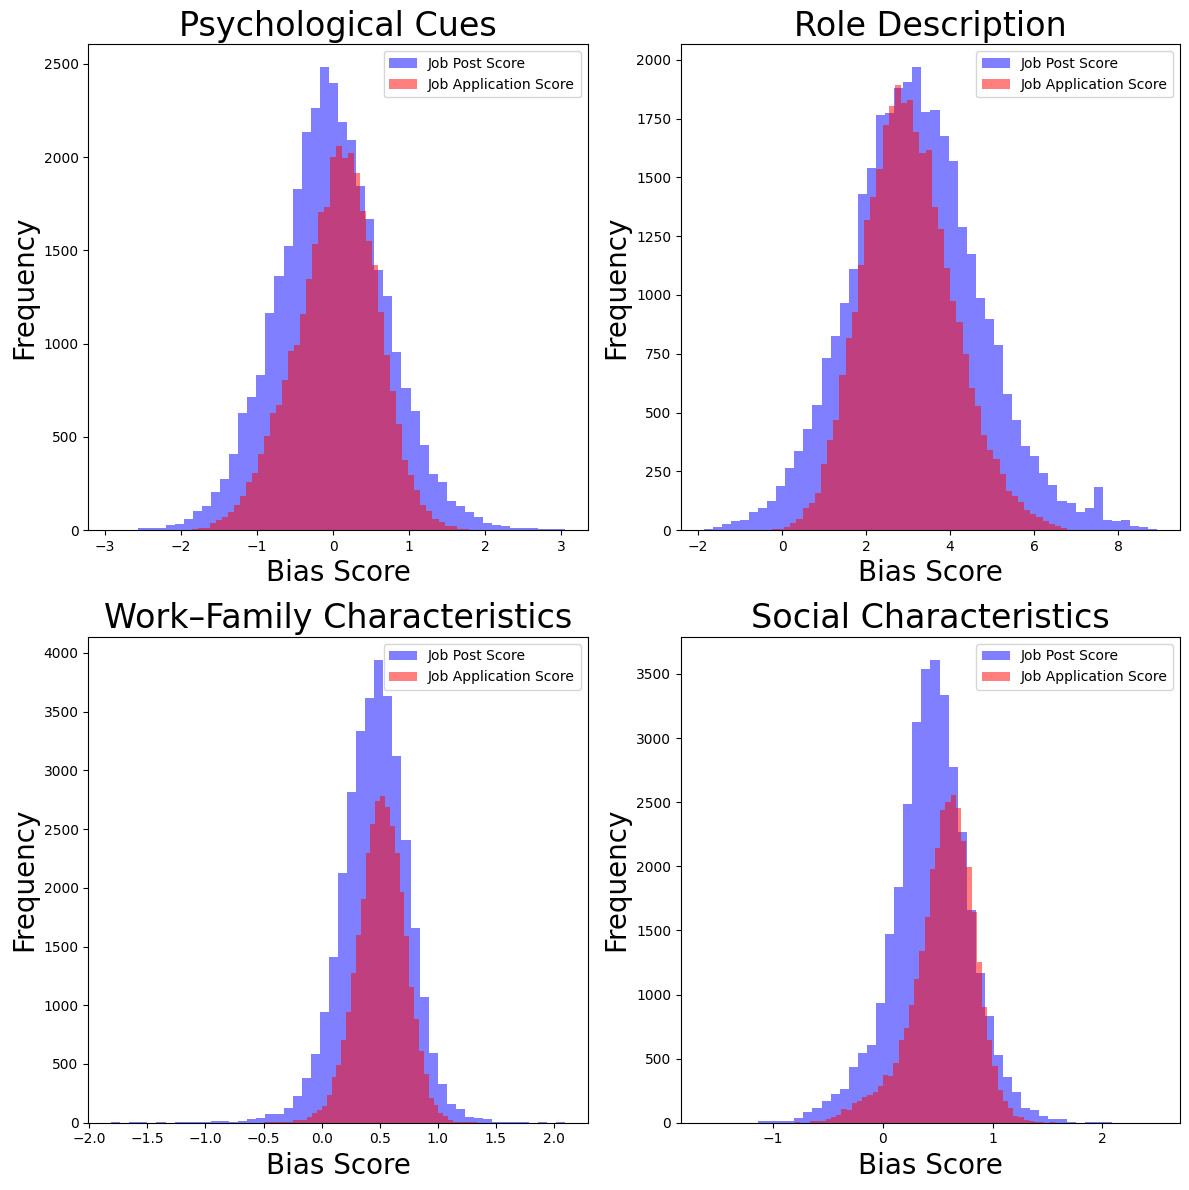

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming result_df_job and result_df_app are defined and contain your data
column_pairs = [(job, app) for job, app in zip(result_df_job.columns, result_df_app.columns)]

# Set up a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 2 rows, 2 columns
axs = axs.flatten()  # Flatten to index it easier in the loop

# Loop through each pair
for i, (col1, col2) in enumerate(column_pairs):
    if i >= 4:  # Only plotting the first four pairs
        break
    filtered_X, filtered_Y, num_filtered, percent_filtered = remove_outliers_with_dbscan(result_df_job[col1], result_df_app[col2])
    print(f"Filtered out {num_filtered} data points ({percent_filtered:.2f}% of the original data).")
    
    if len(filtered_X) > 0 and len(filtered_Y) > 0:  # Ensure there are enough data points to plot
        # Plotting the histograms
        axs[i].hist(filtered_X, bins=50, alpha=0.5, label=f'Job Post Score', color='blue')
        axs[i].hist(filtered_Y, bins=50, alpha=0.5, label=f'Job Application Score', color='red')
        axs[i].set_title(f'{name_list[i]}', fontsize=24)
        axs[i].set_xlabel('Bias Score', fontsize=20)
        axs[i].set_ylabel('Frequency', fontsize=20)
        axs[i].legend()
    else:
        print(f"Not enough data to plot distributions for {col1} vs {col2}")

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


In [176]:
import numpy as np
from scipy.stats import f, levene, shapiro

# Assuming result_df_job and result_df_app are defined and contain your data
column_pairs = [(job, app) for job, app in zip(result_df_job.columns, result_df_app.columns)]

# Loop through each pair
for i, (col1, col2) in enumerate(column_pairs):
    filtered_X, filtered_Y, num_filtered, percent_filtered = remove_outliers_with_dbscan(result_df_job[col1], result_df_app[col2])
    # Print the number of filtered points
    print(f"Filtered out {num_filtered} data points ({percent_filtered:.2f}% of the original data) for job_{col1} and app_{col2}.")

    if len(filtered_X) > 1 and len(filtered_Y) > 1:  # Ensure there are enough data points to perform the tests
        # Check for normality
        shapiro_X_stat, shapiro_X_p = shapiro(filtered_X)
        shapiro_Y_stat, shapiro_Y_p = shapiro(filtered_Y)
        print(f"Shapiro-Wilk test results for job_{col1}: statistic = {shapiro_X_stat}, p-value = {shapiro_X_p}")
        print(f"Shapiro-Wilk test results for app_{col2}: statistic = {shapiro_Y_stat}, p-value = {shapiro_Y_p}")

        # If both groups pass the normality test, perform the F-test
        if shapiro_X_p > 0.05 and shapiro_Y_p > 0.05:
            var_X = np.var(filtered_X, ddof=1)
            var_Y = np.var(filtered_Y, ddof=1)
            F = var_X / var_Y if var_X > var_Y else var_Y / var_X
            df_X = len(filtered_X) - 1
            df_Y = len(filtered_Y) - 1
            if var_X > var_Y:
                f_p_value = 1 - f.cdf(F, df_X, df_Y)  # var_X is hypothesized to be greater
            else:
                f_p_value = f.cdf(F, df_Y, df_X)  # var_Y is hypothesized to be greater
            print(f"F-test (one-sided) results for variances in job_{col1} vs app_{col2}: F-statistic = {F}, p-value = {f_p_value}")
        else:
            print(f"Normality assumption not met for F-test in columns job_{col1} and app_{col2}.")

        # Levene's test - interpretation of one-sided test based on variances
        stat, p_value = levene(filtered_X, filtered_Y)
        var_X = np.var(filtered_X, ddof=1)
        var_Y = np.var(filtered_Y, ddof=1)
        if var_X > var_Y:
            print(f"Levene's test (one-sided interpretation) suggests job_{col1} has greater variance than app_{col2}: Statistic = {stat}, p-value = {p_value / 2}")
        else:
            print(f"Levene's test (one-sided interpretation) suggests app_{col2} has greater variance than job_{col1}: Statistic = {stat}, p-value = {p_value / 2}")



Filtered out 31 data points (0.09% of the original data) for job_psy and app_psy.
Shapiro-Wilk test results for job_psy: statistic = 0.9984488487243652, p-value = 3.288475054050283e-17
Shapiro-Wilk test results for app_psy: statistic = 0.9952604174613953, p-value = 1.5029662001817062e-30
Normality assumption not met for F-test in columns job_psy and app_psy.
Levene's test (one-sided interpretation) suggests job_psy has greater variance than app_psy: Statistic = 1825.0938404489395, p-value = 0.0


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Filtered out 153 data points (0.46% of the original data) for job_role and app_role.
Shapiro-Wilk test results for job_role: statistic = 0.9958909749984741, p-value = 1.4171715958236642e-28
Shapiro-Wilk test results for app_role: statistic = 0.9948095679283142, p-value = 9.077664611160102e-32
Normality assumption not met for F-test in columns job_role and app_role.
Levene's test (one-sided interpretation) suggests job_role has greater variance than app_role: Statistic = 3410.618666855707, p-value = 0.0


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Filtered out 7 data points (0.02% of the original data) for job_wfc and app_wfc.
Shapiro-Wilk test results for job_wfc: statistic = 0.9815707206726074, p-value = 0.0
Shapiro-Wilk test results for app_wfc: statistic = 0.9964144229888916, p-value = 7.628797250852391e-27
Normality assumption not met for F-test in columns job_wfc and app_wfc.
Levene's test (one-sided interpretation) suggests job_wfc has greater variance than app_wfc: Statistic = 2491.08415868273, p-value = 0.0


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Filtered out 8 data points (0.02% of the original data) for job_gsc and app_gsc.
Shapiro-Wilk test results for job_gsc: statistic = 0.9879621267318726, p-value = 8.407790785948902e-45
Shapiro-Wilk test results for app_gsc: statistic = 0.969150722026825, p-value = 0.0
Normality assumption not met for F-test in columns job_gsc and app_gsc.
Levene's test (one-sided interpretation) suggests job_gsc has greater variance than app_gsc: Statistic = 922.186013547498, p-value = 1.7967956503634076e-201


/home/leiding/pyotrch/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
